# Smartwatch Rating Prediction

### Objective

- The purpose of this notebook is to understand the dataset through statistical summaries and visualizations. We identify patterns, missing values, outliers, feature distributions, and relationships between variables that will guide preprocessing and model development.

### Workflow

1. Load cleaned dataset
2. Dataset overview
3. Statistical summary
4. Univariate Analysis
5. Bivariate Analysis
6. Correlation Analysis
7. Key Insights

In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
DATA_PATH = Path.cwd().parent / "Dataset" / "Processed" / "cleaned_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight,Weight_missing,reviews_placeholder_flag,price_logic_flag
0,noise,82990.0,89900.0,7.686318,4.0,65.0,Wrb-sw-colorfitpro4alpha-std-rgld_pnk,Missing,Missing,Missing,1,8.0,1,1.5,35 - 50 g,0,False,False
1,fire-boltt,3799.0,16999.0,77.651627,4.3,20788.0,BSW046,Missing,Missing,Silicon,1,3.5,1,1.8,50 - 75 g,0,False,False
2,boat,1999.0,7990.0,74.981227,3.8,21724.0,Wave Call,Missing,Missing,Silicon,1,8.0,1,1.7,35 - 50 g,0,False,False
3,fire-boltt,1799.0,19999.0,91.004550,4.3,13244.0,BSW053,Missing,Missing,Silicon,1,3.5,1,1.8,75g +,0,False,False
4,noise,1599.0,4999.0,68.013603,4.1,13901.0,Wrb-sw-colorfitpulsegobuzz-std-blk_blk,Missing,Missing,Other,1,8.0,1,1.7,35 - 50 g,0,False,False


In [3]:
df.shape

(347, 18)

In [4]:
df.describe()

,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight_missing
count,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000,347.000000
mean,9935.057637,15098.878963,47.957203,4.059366,12307.334294,0.965418,13.743500,0.997118,1.405187,0.386167
std,14718.562274,15974.247142,22.156996,0.429669,42708.384100,0.182983,7.342805,0.053683,0.517360,0.487573
min,1199.000000,1899.000000,0.003040,1.000000,1.000000,0.000000,0.750000,0.000000,0.100000,0.000000
25%,1999.000000,5999.000000,32.698596,3.900000,109.000000,1.000000,8.000000,1.000000,1.300000,0.000000
50%,3499.000000,7999.000000,51.551357,4.100000,996.000000,1.000000,14.077392,1.000000,1.500000,0.000000
75%,11599.000000,19990.000000,66.276787,4.300000,6553.500000,1.000000,22.000000,1.000000,1.700000,1.000000
max,89490.000000,96390.000000,91.004550,5.000000,619130.000000,1.000000,22.000000,1.000000,3.000000,1.000000


In [5]:
df.isnull().sum()

Brand                       0
Current Price               0
Original Price              0
Discount Percentage         0
Rating                      0
Number OF Ratings           0
Model Name                  0
Dial Shape                  0
Strap Color                 0
Strap Material              0
Touchscreen                 0
Battery Life (Days)         0
Bluetooth                   0
Display Size                0
Weight                      0
Weight_missing              0
reviews_placeholder_flag    0
price_logic_flag            0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Brand                     347 non-null    object 
 1   Current Price             347 non-null    float64
 2   Original Price            347 non-null    float64
 3   Discount Percentage       347 non-null    float64
 4   Rating                    347 non-null    float64
 5   Number OF Ratings         347 non-null    float64
 6   Model Name                347 non-null    object 
 7   Dial Shape                347 non-null    object 
 8   Strap Color               347 non-null    object 
 9   Strap Material            347 non-null    object 
 10  Touchscreen               347 non-null    int64  
 11  Battery Life (Days)       347 non-null    float64
 12  Bluetooth                 347 non-null    int64  
 13  Display Size              347 non-null    float64
 14  Weight    

# *<u>Univariate Analysis:</u>*

# **Numerical Features:**

# Rating:

Text(0.5, 1.0, 'Distribution of Rating')

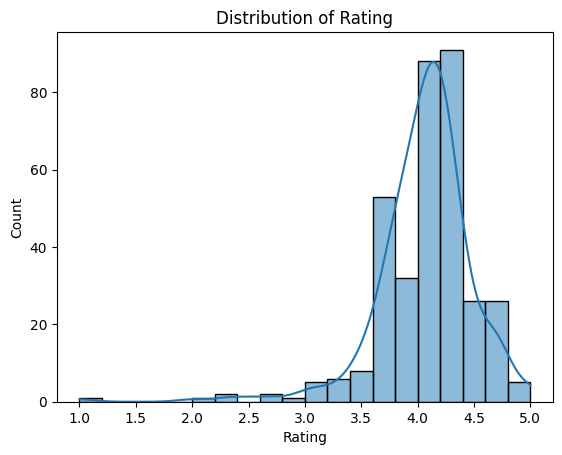

In [7]:
plt.Figure(figsize=(8,6))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Distribution of Rating")

# Current Price:

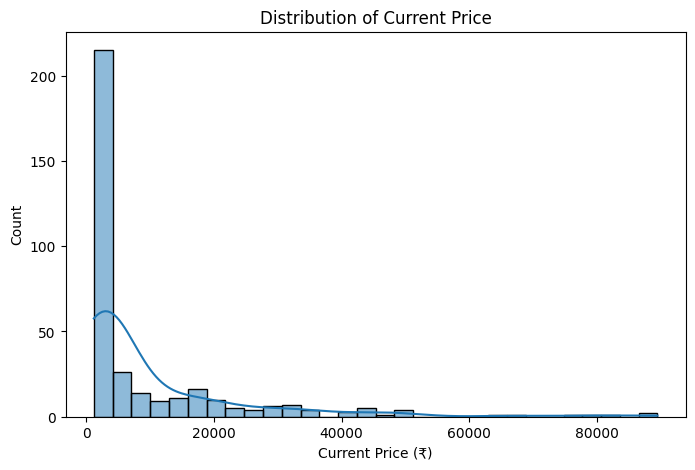

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Current Price"], bins=30, kde=True)

plt.title("Distribution of Current Price")
plt.xlabel("Current Price (₹)")
plt.ylabel("Count")

plt.show()

Observation 1:

- The distribution of Current Price is highly right-skewed, indicating that most smartwatches belong to the budget segment, while only a few products are priced in the premium range.

Observation 2:

- The high standard deviation confirms that prices vary considerably across products, reflecting the presence of both low-cost and high-end smartwatches.

Observation 3:

- The right-skewed distribution suggests that the mean price is likely to be higher than the median due to the influence of a few expensive products.

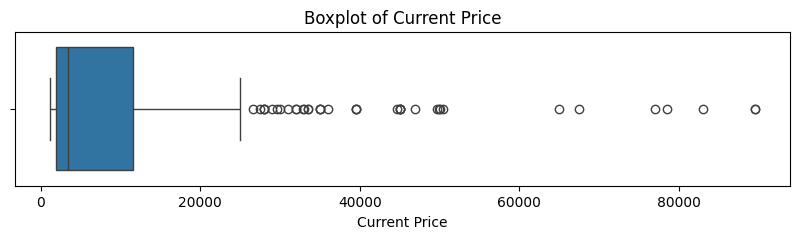

In [9]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Current Price"])

plt.title("Boxplot of Current Price")

plt.show()

Distribution Analysis:
- The distribution of Current Price is highly right-skewed.
- Most smartwatches are priced below ₹20,000.
- Only a small number of premium smartwatches are available at very high prices.

Boxplot Analysis:
- The boxplot reveals several high-price outliers.
- These outliers are located on the higher price side.
- Based on domain knowledge, these values are likely genuine premium smartwatch prices rather than data entry errors.


# Insight:

- The dataset primarily consists of budget smartwatches, with a limited number of premium products. The high-price outliers appear to represent real market products and should be verified before considering any treatment.

# Original Price:

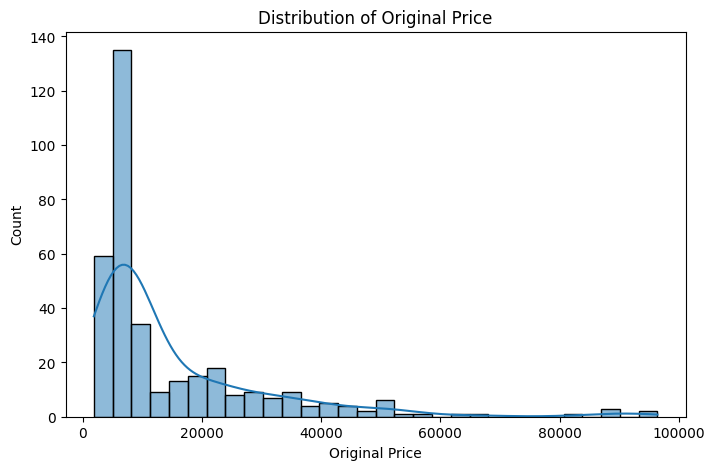

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Original Price"], bins=30, kde=True)

plt.title("Distribution of Original Price")
plt.xlabel("Original Price")
plt.ylabel("Count")

plt.show()

## Distribution Analysis (Histogram)
Observation 1:

- The distribution of Original Price is highly right-skewed, indicating that most smartwatches have lower original prices, while only a few products belong to the premium price segment.

Observation 2:

- The majority of smartwatches have an original price below ₹20,000, suggesting that the dataset primarily consists of budget and mid-range products.

Observation 3:

- A small number of products have exceptionally high original prices, resulting in a long right tail in the distribution.

Observation 4:

- Since the distribution is right-skewed, the mean original price is expected to be higher than the median, as a few expensive products pull the average upward.

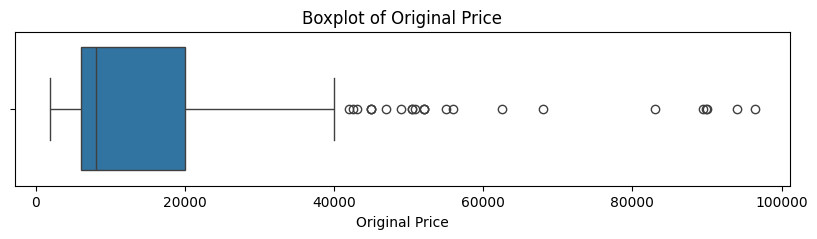

In [11]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Original Price"])

plt.title("Boxplot of Original Price")

plt.show()

## Boxplot Analysis

Observation 1:

- The boxplot reveals several high-value outliers in the Original Price feature.

Observation 2:

- These outliers are present only on the higher price side, further confirming the right-skewed nature of the distribution.

Observation 3: 

- Based on domain knowledge, these high-price observations appear to represent genuine premium smartwatches rather than data entry errors. Therefore, they should be verified before considering any treatment.

## Insight:

- The dataset contains smartwatches from multiple pricing categories, including budget, mid-range, and premium products. However, the majority of products belong to the budget and mid-range segments, while premium smartwatches constitute only a small portion of the dataset.

# Number of Ratings:

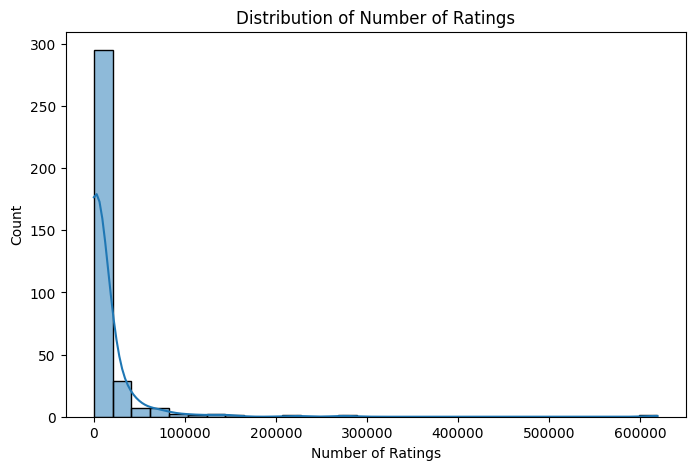

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Number OF Ratings"], bins=30, kde=True)

plt.title("Distribution of Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Count")

plt.show()

## Histogram Analysis


Observation 1:

- The Number of Ratings feature is highly right-skewed and does not follow a normal distribution.

Observation 2:

- Most products have received a relatively small number of customer ratings, while only a few products have accumulated a very large number of reviews.

Observation 3:

- The long right tail indicates the presence of a few highly popular smartwatches.

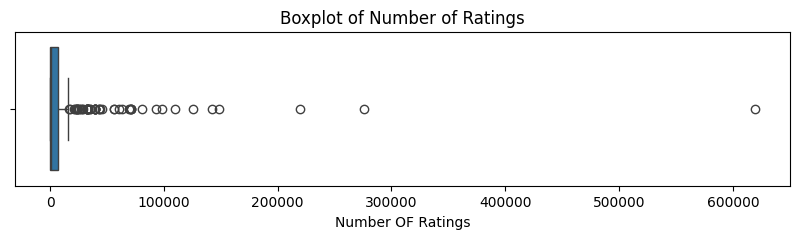

In [13]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Number OF Ratings"])

plt.title("Boxplot of Number of Ratings")

plt.show()

## Boxplot Analysis

Observation 1:

- The boxplot identifies several high-value outliers in the Number of Ratings feature.

Observation 2:

- These outliers most likely represent highly popular products rather than data entry errors.

## Insight:

- The dataset contains a small number of highly popular smartwatches with exceptionally large numbers of customer ratings, whereas the majority of products have comparatively fewer reviews.

## Battery Life (Days):

In [14]:
print(df["Battery Life (Days)"].describe())
print('\n')
print(df["Battery Life (Days)"].skew())
print(df["Battery Life (Days)"].median())
print(df["Battery Life (Days)"].mean())

count    347.000000
mean      13.743500
std        7.342805
min        0.750000
25%        8.000000
50%       14.077392
75%       22.000000
max       22.000000
Name: Battery Life (Days), dtype: float64


-0.08223648603386391
14.077392344497609
13.743499648387408


### Observations:

- The average battery life of smartwatches is 14.28 days.
- The median battery life is 14.08 days, which is very close to the mean.
- The feature has a slight negative skewness (-0.25), indicating that the distribution is approximately symmetric with a mild left skew.
- The battery life ranges from 0.75 days to 22 days, covering products with varying battery capacities.

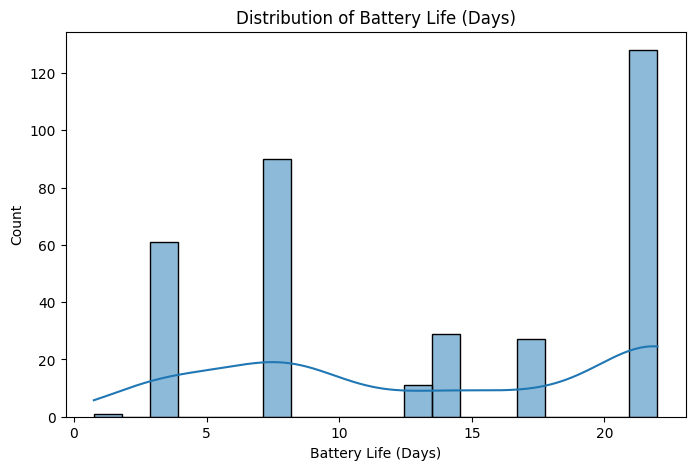

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Battery Life (Days)"], bins=20, kde=True)

plt.title("Distribution of Battery Life (Days)")
plt.xlabel("Battery Life (Days)")
plt.ylabel("Count")

plt.show()

### Observations:

- The distribution is approximately symmetric with a slight left skew.
- Most smartwatches have a battery life between 12 and 22 days.
- Only a small number of products have relatively lower battery life.

In [16]:
df["Battery Life (Days)"].skew()

np.float64(-0.08223648603386391)

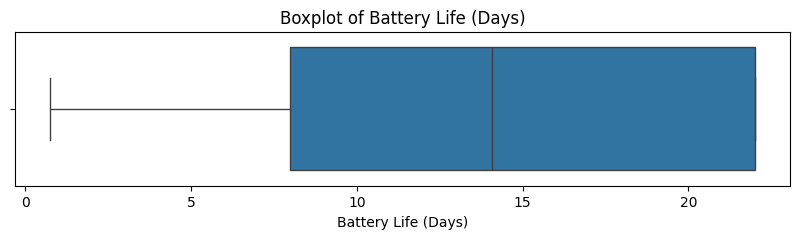

In [17]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Battery Life (Days)"])

plt.title("Boxplot of Battery Life (Days)")

plt.show()

### Observations:

- The boxplot does not indicate any significant outliers.
- The absence of extreme values suggests that battery life is relatively consistent across products.

### Insight:

- Most smartwatches in the dataset provide around two weeks of battery life, while only a few models offer significantly shorter battery backup. This suggests that manufacturers generally maintain a similar battery performance across products.
- Since the feature exhibits only mild skewness and no significant outliers, no transformation is required before model training.

## Display Size:

In [18]:
df["Display Size"].describe()

count    347.000000
mean       1.405187
std        0.517360
min        0.100000
25%        1.300000
50%        1.500000
75%        1.700000
max        3.000000
Name: Display Size, dtype: float64

### Observation:

- The average display size is approximately 1.4 inches.
- The feature exhibits high negative skewness (-1.365).
- The mean is lower than the median, supporting the left-skewed distribution.

In [19]:
print(df["Display Size"].skew())

-1.3348751724651544


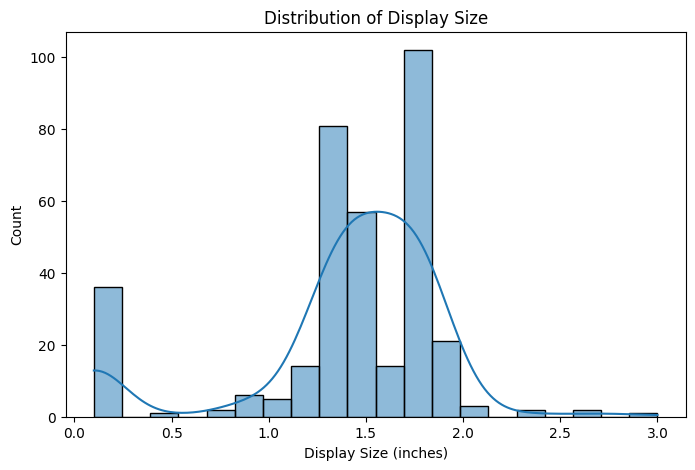

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["Display Size"], bins=20, kde=True)

plt.title("Distribution of Display Size")
plt.xlabel("Display Size (inches)")
plt.ylabel("Count")

plt.show()

### Observation: 

- Most smartwatches have display sizes close to 1.5 inches.
- The distribution is highly left-skewed, indicating the presence of relatively smaller display size values.

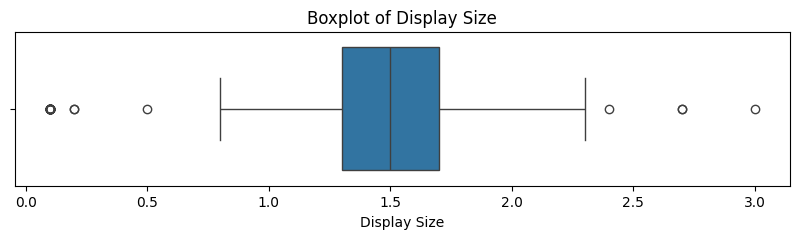

In [21]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Display Size"])

plt.title("Boxplot of Display Size")

plt.show()

### Observation:

- The boxplot reveals several outliers on both ends of the distribution.
- Extremely small values (such as 0 inches) appear unrealistic and should be investigated.
- Larger display size values should be verified before deciding whether they are genuine observations or extraction errors.

### Insight:

- Most smartwatches in the dataset have display sizes around 1.5 inches, suggesting a fairly standardized display size across products. Only a few products deviate noticeably from this range.

## Weight: 

In [22]:
df['Weight'].describe()

count           347
unique            5
top       20 - 35 g
freq            197
Name: Weight, dtype: object

### Observation:

- The average smartwatch weight is approximately 20-35 g.
- The distribution exhibits a slight negative skew.
- The mean is slightly lower than the median, supporting the observed skewness.

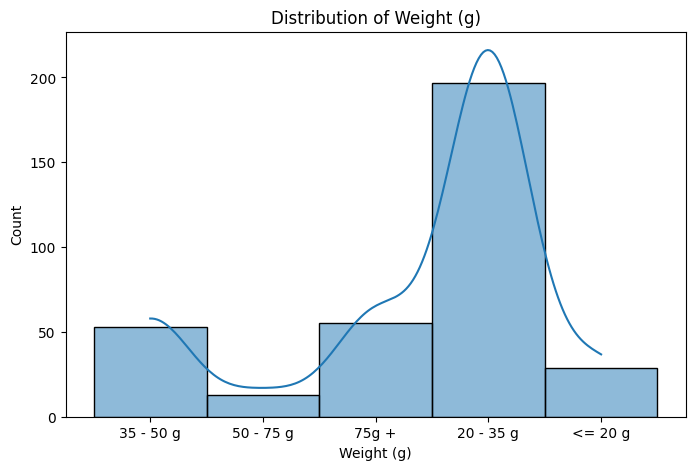

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["Weight"], bins=20, kde=True)

plt.title("Distribution of Weight (g)")
plt.xlabel("Weight (g)")
plt.ylabel("Count")

plt.show()

### Observation:

- Most smartwatches have weights concentrated within a narrow range.
- The feature is approximately symmetric with a slight left skew.

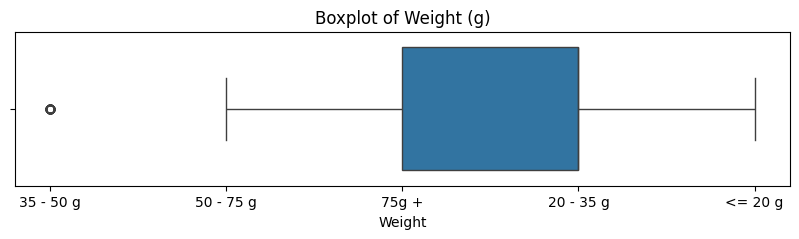

In [24]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["Weight"])

plt.title("Boxplot of Weight (g)")

plt.show()

### Observation:

- The boxplot identifies one potential outlier.
- This observation should be verified to determine whether it represents a genuine product specification or a data quality issue.

### Insight:

- Most smartwatches are lightweight, indicating that manufacturers generally design them for comfortable everyday use. Only a few products have noticeably different weights.

## Discount Percentage:

In [25]:
df["Discount Percentage"].describe()

count    347.000000
mean      47.957203
std       22.156996
min        0.003040
25%       32.698596
50%       51.551357
75%       66.276787
max       91.004550
Name: Discount Percentage, dtype: float64

In [26]:
print(df["Discount Percentage"].skew())

-0.5174589375002401


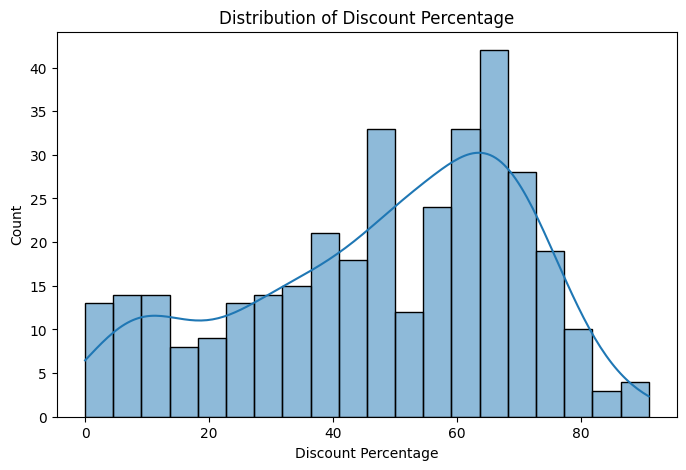

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Discount Percentage"],
    bins=20,
    kde=True
)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Count")

plt.show()

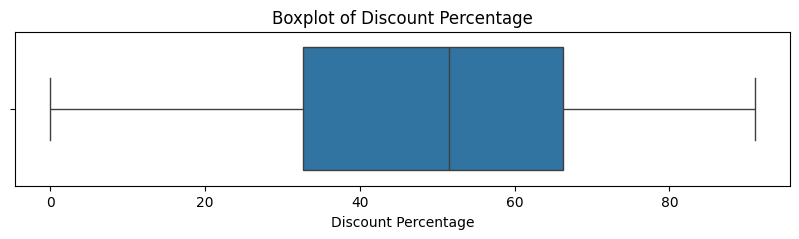

In [28]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Discount Percentage"]
)

plt.title("Boxplot of Discount Percentage")

plt.show()

In [29]:
df[df["Discount Percentage"] < 0]

,Brand,Current Price,Original Price,Discount Percentage,Rating,Number OF Ratings,Model Name,Dial Shape,Strap Color,Strap Material,Touchscreen,Battery Life (Days),Bluetooth,Display Size,Weight,Weight_missing,reviews_placeholder_flag,price_logic_flag


In [30]:
df[df["Discount Percentage"] < 0][
    ["Brand", "Model Name", "Current Price", "Original Price", "Discount Percentage"]
]

,Brand,Model Name,Current Price,Original Price,Discount Percentage


In [31]:
df[df["Discount Percentage"] < 0][
    ["Current Price", "Original Price", "Discount Percentage"]
].head(10)

,Current Price,Original Price,Discount Percentage


In [32]:
(df["Current Price"] > df["Original Price"]).sum()

np.int64(0)

## Insight:

- The Discount Percentage feature exhibits a highly left-skewed distribution due to 67 records where the current price exceeds the original price, resulting in negative discount values. The dataset already includes a price_logic_flag to identify these pricing anomalies. These records were retained for analysis, and the usefulness of the Discount Percentage feature will be evaluated during feature selection and model training.

# **Categorical Features:**

## Brand:

In [33]:
df['Brand'].value_counts()

Brand
noise         43
Other         39
fire-boltt    35
zebronics     33
pebble        32
garmin        32
samsung       28
boat          27
gizmore       22
dizo          21
huawei        13
fossil         9
fitbit         7
apple          6
Name: count, dtype: int64

### Observation:

- The dataset contains multiple smartwatch brands, with Fire-Boltt having the highest number of products and Hammer having the fewest.

In [34]:
df['Brand'].value_counts(normalize=True)*100

Brand
noise         12.391931
Other         11.239193
fire-boltt    10.086455
zebronics      9.510086
pebble         9.221902
garmin         9.221902
samsung        8.069164
boat           7.780980
gizmore        6.340058
dizo           6.051873
huawei         3.746398
fossil         2.593660
fitbit         2.017291
apple          1.729107
Name: proportion, dtype: float64

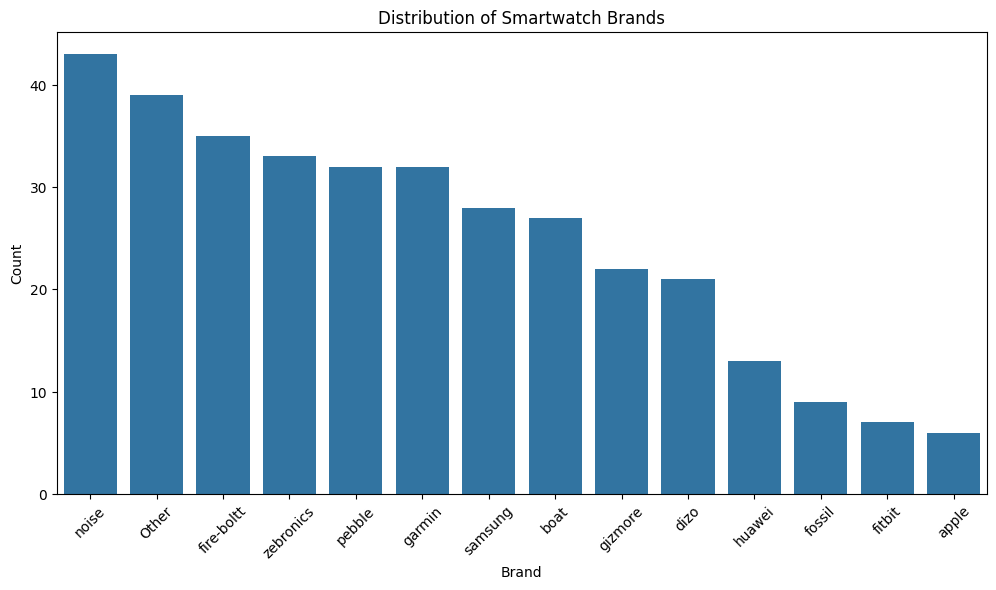

In [35]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Brand",
    order=df["Brand"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Smartwatch Brands")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.show()

### Observation: 

- The distribution of products across brands is not uniform. Some brands contribute substantially more products than others.


### Insight:

- A few brands dominate the dataset in terms of product representation, while several other brands contribute comparatively fewer products.

## Dial Shape:

In [36]:
df["Dial Shape"].value_counts()

Dial Shape
Missing      103
Circle       101
Square        78
Rectangle     61
Other          4
Name: count, dtype: int64

### Observation:

- The dataset contains multiple dial shapes.
- Circular dials are the most common, whereas oval dials are the least represented.

In [37]:
df["Dial Shape"].value_counts(normalize=True)*100

Dial Shape
Missing      29.682997
Circle       29.106628
Square       22.478386
Rectangle    17.579251
Other         1.152738
Name: proportion, dtype: float64

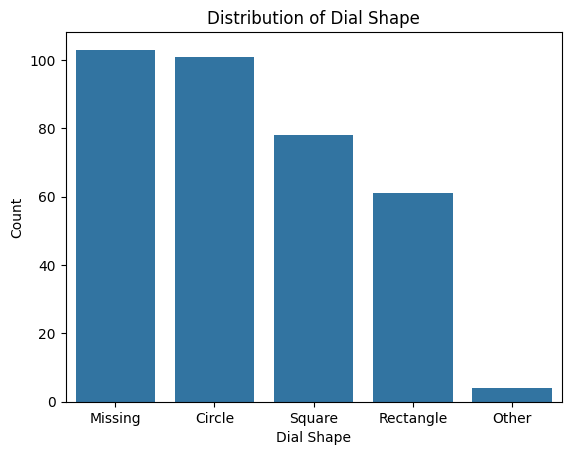

In [38]:
plt.Figure(figsize=(6,8))
sns.countplot(data=df, x='Dial Shape', order=df['Dial Shape'].value_counts().index)
plt.title("Distribution of Dial Shape")
plt.xlabel("Dial Shape")
plt.ylabel("Count")

plt.show()

### Observation:

- The distribution is moderately imbalanced.
- Circular dial smartwatches dominate the dataset.

### Insight:

- Circular dial smartwatches have the highest representation in the dataset, suggesting that this design is more commonly available among the listed products.

## Bluetooth:

In [39]:
df["Bluetooth"].value_counts()

Bluetooth
1    346
0      1
Name: count, dtype: int64

### Observation:

- The majority of smartwatches support Bluetooth connectivity.
- Only a small proportion of products do not include Bluetooth support.

In [40]:
df["Bluetooth"].value_counts(normalize=True)*100

Bluetooth
1    99.711816
0     0.288184
Name: proportion, dtype: float64

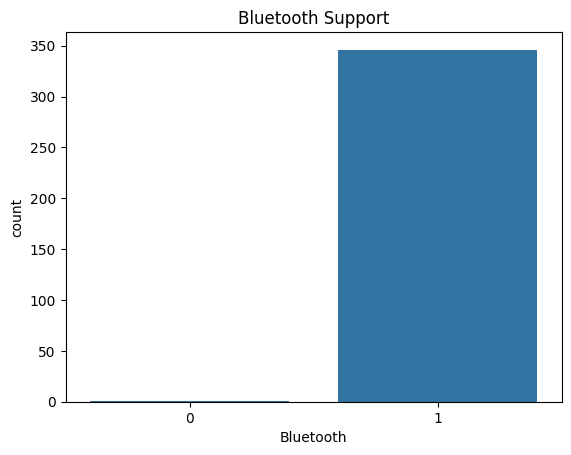

In [41]:
plt.Figure(figsize=(5,4))
sns.countplot(data=df, x="Bluetooth")
plt.title("Bluetooth Support")
plt.show()

### Observation:

- The distribution is imbalanced, with Bluetooth-enabled smartwatches dominating the dataset.

## Insight:

Since Bluetooth is a binary categorical feature, it can be encoded using 0 and 1 (No = 0, Yes = 1), which is more efficient than One-Hot Encoding.

## Touchscreen:

In [42]:
df["Touchscreen"].value_counts()

Touchscreen
1    335
0     12
Name: count, dtype: int64

### Observation:

- Most smartwatches in the dataset support touchscreen functionality.
- The Yes category has a much higher frequency than the No category.

In [43]:
(df["Touchscreen"].value_counts(normalize=True) * 100).round(2)

Touchscreen
1    96.54
0     3.46
Name: proportion, dtype: float64

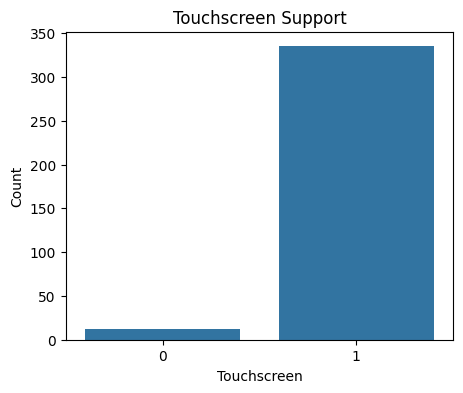

In [44]:
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="Touchscreen")

plt.title("Touchscreen Support")
plt.xlabel("Touchscreen")
plt.ylabel("Count")

plt.show()

### Observations:

- The Touchscreen feature is imbalanced.
- Smartwatches with touchscreen support dominate the dataset.

## Insight:

- Touchscreen functionality is present in the majority of smartwatches in the dataset, suggesting that it has become a common feature among the listed products.

## Strap Material:

In [45]:
df["Strap Material"].value_counts()

Strap Material
Silicon            189
Missing             59
Other               54
Rubber              24
Leather             11
Stainless Steel     10
Name: count, dtype: int64

### Observation:

- The dataset contains multiple strap materials.
- Silicon is the most frequently occurring strap material, while Nylon has the lowest representation.

In [46]:
df["Strap Material"].value_counts(normalize=True)*100

Strap Material
Silicon            54.466859
Missing            17.002882
Other              15.561960
Rubber              6.916427
Leather             3.170029
Stainless Steel     2.881844
Name: proportion, dtype: float64

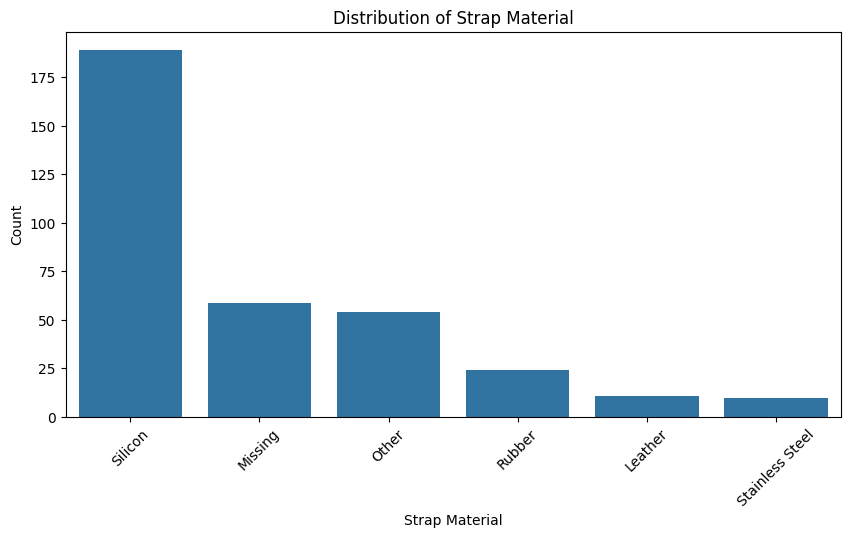

In [47]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Strap Material",
    order=df["Strap Material"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Distribution of Strap Material")
plt.xlabel("Strap Material")
plt.ylabel("Count")

plt.show()

### Observations:

- The Strap Material feature is highly imbalanced.
- Silicon dominates the dataset, whereas other materials appear much less frequently.

### Insight:

- Silicon straps have the highest representation among the listed smartwatch models, suggesting that they are commonly used across products in the dataset.

## Strap Color:

In [48]:
df["Strap Color"].value_counts()

Strap Color
Black      104
Missing    103
Other       86
Blue        27
Grey        27
Name: count, dtype: int64

### Observation:

- The dataset contains multiple strap colors.
- Black is the most common strap color, while Sea Green has the lowest representation.

In [49]:
(df["Strap Color"].value_counts(normalize=True) * 100).round(2)

Strap Color
Black      29.97
Missing    29.68
Other      24.78
Blue        7.78
Grey        7.78
Name: proportion, dtype: float64

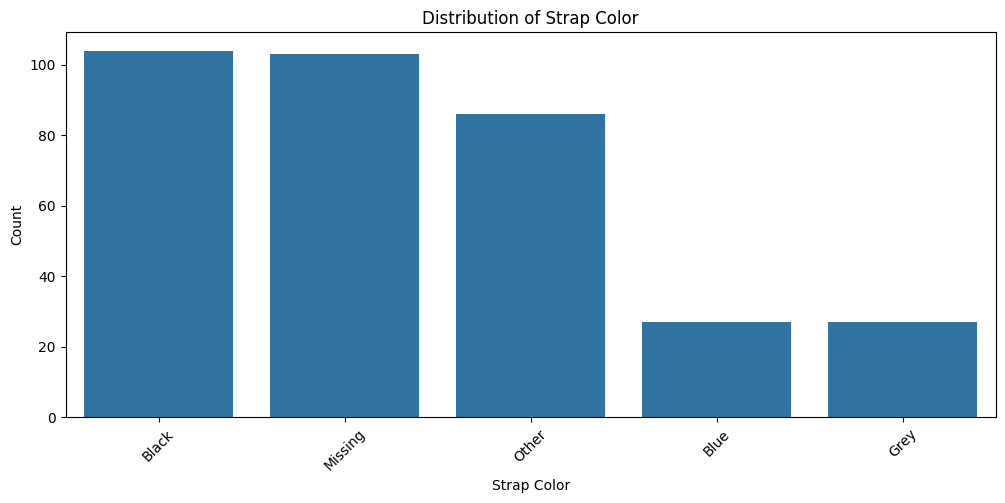

In [50]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Strap Color",
    order=df["Strap Color"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Distribution of Strap Color")
plt.xlabel("Strap Color")
plt.ylabel("Count")

plt.show()

### Observation:

- The Strap Color feature is highly imbalanced.
- Black dominates the dataset, whereas several other colors occur much less frequently.

## Insight: 

- Black strap smartwatches have the highest representation in the dataset, indicating that black is the most commonly available strap color among the listed smartwatch models.

# Note:
- The Model Name column acts as a product identifier with high cardinality. Therefore, detailed univariate analysis was not performed, and it is likely to be excluded during model training.

# *<u>Bivariate Analysis: </u>*

# **Numerical Features:**

## Current Price VS Rating

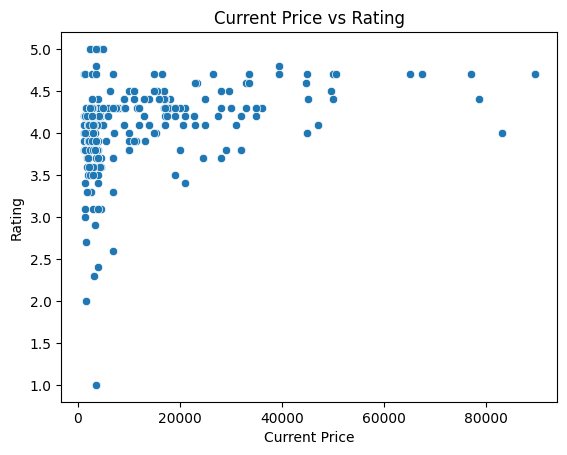

In [51]:
plt.Figure(figsize=(8,5))
sns.scatterplot( x=df['Current Price'], y=df['Rating'])

plt.title("Current Price vs Rating")
plt.xlabel("Current Price")
plt.ylabel("Rating")

plt.show()

### Observation

- The scatter plot shows a slight upward trend, although the data points are widely scattered. This indicates that the relationship between Current Price and Rating is weak.

In [52]:
df[["Current Price","Rating"]].corr()

,Current Price,Rating
Current Price,1.000000,0.344471
Rating,0.344471,1.000000


### Observation:

- The correlation coefficient between Current Price and Rating is 0.386, indicating a weak positive linear relationship. As the current price increases, ratings tend to increase slightly, but the association is not strong.

## Original Price VS Rating

In [53]:
df[["Original Price", "Rating"]].corr()

,Original Price,Rating
Original Price,1.000000,0.355186
Rating,0.355186,1.000000


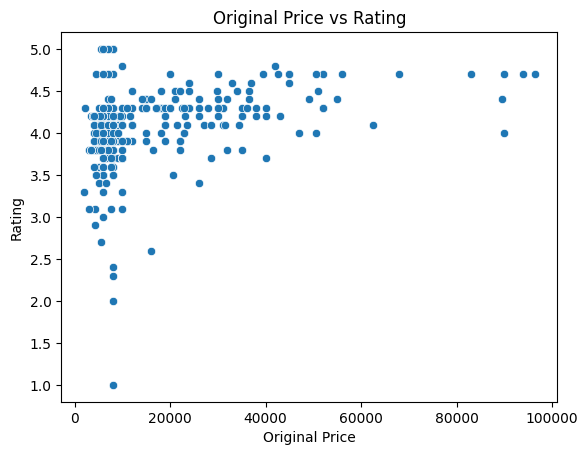

In [54]:
plt.Figure(figsize=(8,5))

sns.scatterplot(data=df, x='Original Price', y='Rating')

plt.title("Original Price vs Rating")
plt.xlabel("Original Price")
plt.ylabel("Rating")

plt.show()

## Discount Percentage vs Rating

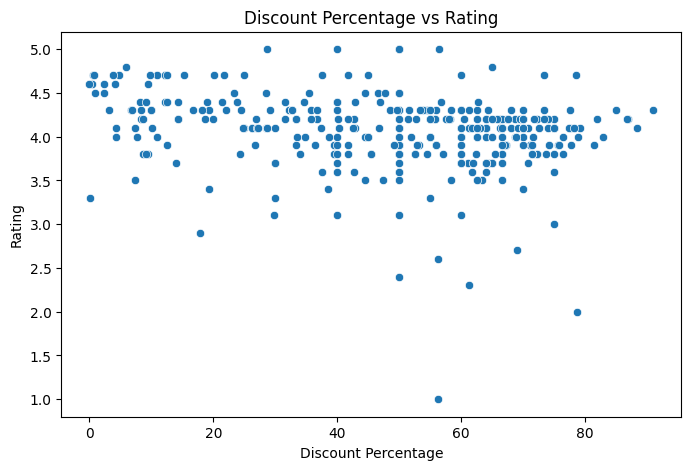

In [55]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Discount Percentage",
    y="Rating"
)

plt.title("Discount Percentage vs Rating")
plt.xlabel("Discount Percentage")
plt.ylabel("Rating")

plt.show()

### Observation:

- The scatter plot does not show a strong linear pattern. The data points are widely scattered, indicating a weak relationship between Discount Percentage and Rating.

In [56]:
df[["Discount Percentage","Rating"]].corr()

,Discount Percentage,Rating
Discount Percentage,1.000000,-0.244077
Rating,-0.244077,1.000000


### Observation:

- The correlation coefficient is -0.288, indicating a weak negative linear relationship. As discount percentage increases, ratings tend to decrease slightly.

### Insight:

- Products with larger discounts tend to have slightly lower customer ratings. However, the relationship is weak, suggesting that discount percentage alone has limited influence on customer ratings.

## Number of Ratings VS Ratings

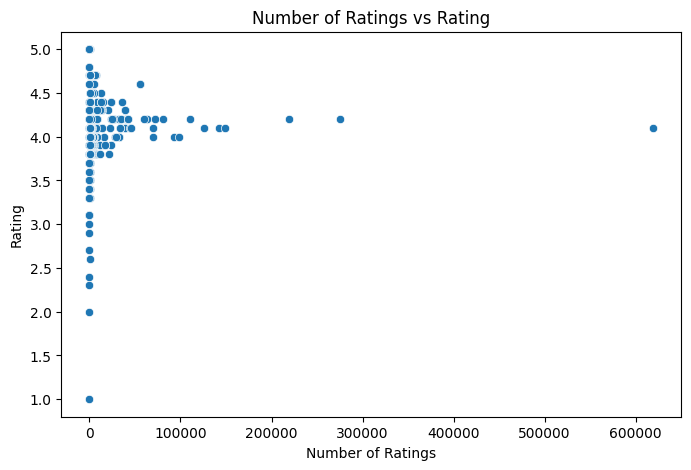

In [57]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Number OF Ratings",
    y="Rating"
)

plt.title("Number of Ratings vs Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Rating")

plt.show()

### Observation:

- The scatter plot shows a random distribution of data points with no clear upward or downward trend.

In [58]:
df[["Number OF Ratings", "Rating"]].corr()

,Number OF Ratings,Rating
Number OF Ratings,1.000000,0.062887
Rating,0.062887,1.000000


### Observation:

- The correlation coefficient between Number of Ratings and Rating is 0.056, indicating an almost negligible positive linear relationship.


## Insight:

- The number of customer ratings does not appear to have a meaningful linear relationship with the product rating. Products with more reviews do not necessarily receive higher or lower ratings.

# Battery Life (Days) vs Rating

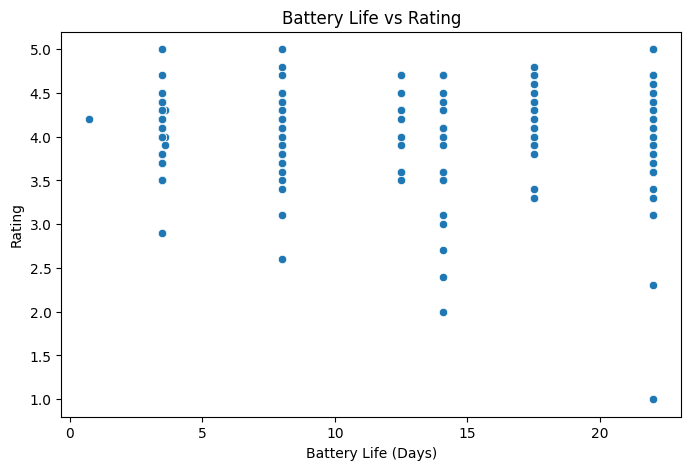

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Battery Life (Days)",
    y="Rating"
)

plt.title("Battery Life vs Rating")
plt.xlabel("Battery Life (Days)")
plt.ylabel("Rating")

plt.show()

### Observation:

- The scatter plot shows a random distribution of data points with no clear linear trend.

In [60]:
df[["Battery Life (Days)", "Rating"]].corr()

,Battery Life (Days),Rating
Battery Life (Days),1.000000,0.001276
Rating,0.001276,1.000000


### Observation:

- The correlation coefficient between Battery Life (Days) and Rating is -0.090, indicating a very weak negative linear relationship.

## Display Size VS Rating

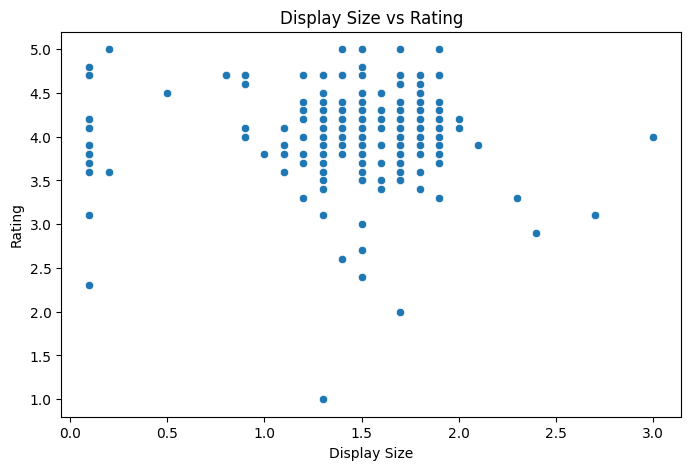

In [61]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Display Size",
    y="Rating"
)

plt.title("Display Size vs Rating")
plt.xlabel("Display Size")
plt.ylabel("Rating")

plt.show()

### Observation:

- The scatter plot shows a random distribution of data points with no clear upward or downward trend. Most products have display sizes between 1 and 2 inches, and ratings are spread across this range.

In [62]:
df[["Display Size", "Rating"]].corr()

,Display Size,Rating
Display Size,1.000000,0.012782
Rating,0.012782,1.000000


### Observations:

- The correlation coefficient between Display Size and Rating is -0.072, indicating a very weak negative linear relationship.

### Insight:

- Display Size does not appear to have a meaningful linear relationship with customer ratings. Products with different display sizes receive similar ratings, suggesting that display size alone has little influence on customer satisfaction.

## Weight VS Rating

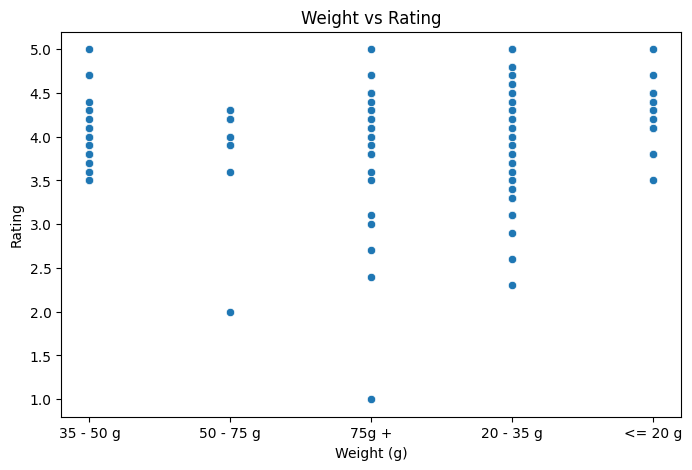

In [63]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Weight",
    y="Rating"
)

plt.title("Weight vs Rating")
plt.xlabel("Weight (g)")
plt.ylabel("Rating")

plt.show()

In [64]:
df['Weight'].value_counts()

Weight
20 - 35 g    197
75g +         55
35 - 50 g     53
<= 20 g       29
50 - 75 g     13
Name: count, dtype: int64

In [65]:
df.groupby("Weight")["Rating"].mean().sort_values(ascending=False)

Weight
<= 20 g      4.268966
20 - 35 g    4.065482
35 - 50 g    4.013208
75g +        4.003636
50 - 75 g    3.923077
Name: Rating, dtype: float64

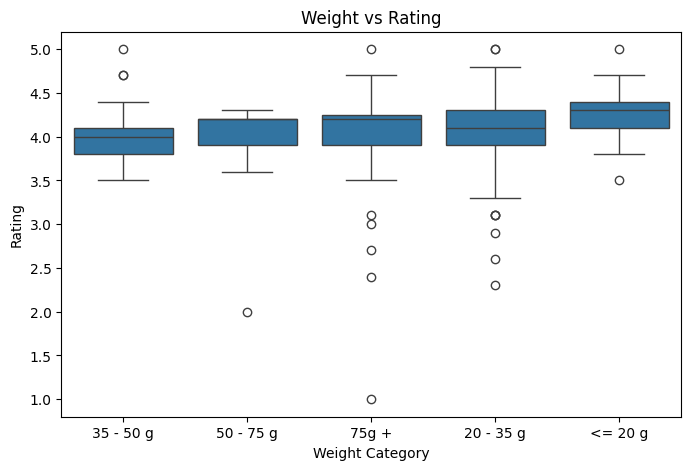

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Weight",
    y="Rating"
)

plt.title("Weight vs Rating")
plt.xlabel("Weight Category")
plt.ylabel("Rating")

plt.show()

### Observation:

- The ≤20 g weight category has the highest median customer rating and shows relatively consistent ratings with a smaller spread. The 20–35 g and 75 g+ categories exhibit greater variability in ratings. Several outliers are present across different weight categories.

### Insight

- Lightweight smartwatches (≤20 g) tend to receive slightly higher customer ratings. However, the rating distributions overlap considerably across all weight categories, indicating that weight alone is not a major factor influencing customer satisfaction.

# **Categorical Columns:**

## Brand VS Rating

In [67]:
brand_rating=(df.groupby('Brand')['Rating'].mean().sort_values())

print(brand_rating)

Brand
zebronics     3.636364
gizmore       3.931818
pebble        3.950000
dizo          3.952381
fossil        3.955556
fire-boltt    3.988571
boat          4.029630
noise         4.069767
Other         4.153846
samsung       4.217857
fitbit        4.228571
garmin        4.362500
huawei        4.384615
apple         4.566667
Name: Rating, dtype: float64


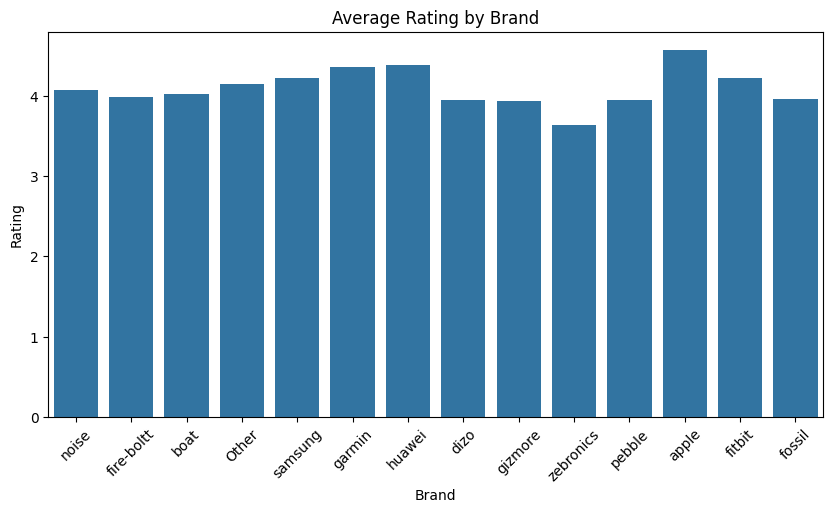

In [68]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Brand",
    y="Rating",
    estimator="mean",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Average Rating by Brand")
plt.show()

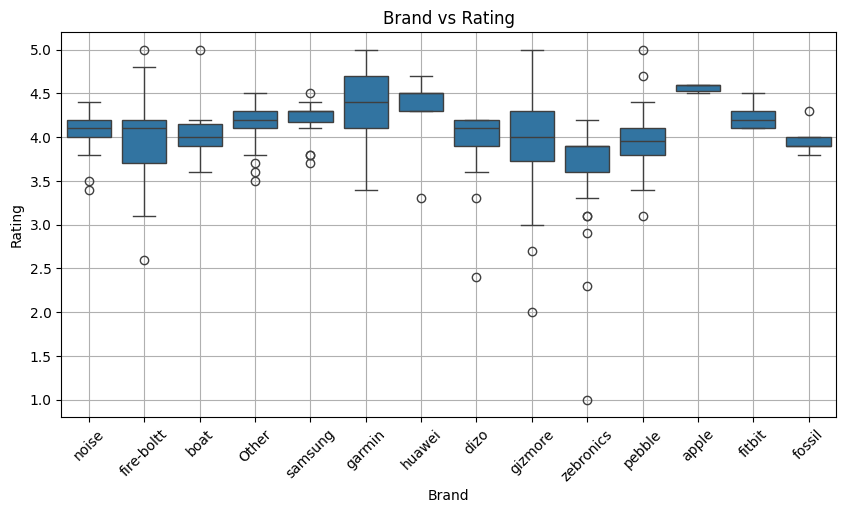

In [69]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Brand",
    y="Rating"
)

plt.xticks(rotation=45)
plt.title("Brand vs Rating")
plt.grid()
plt.show()

### Observation:

- Apple has the highest average customer rating, while Fire-Boltt has the lowest average rating in the dataset.
- The differences in average ratings across brands are relatively small, indicating that most brands have similar customer ratings.
- The box plot shows that Apple, Garmin, and Fitbit have relatively higher median ratings.
- Fire-Boltt and Gizmore exhibit greater variability in customer ratings compared to other brands.
- Several brands contain outliers, indicating that some products receive exceptionally high or low ratings.

## Insight:

- Most brands receive ratings above 4.0, indicating generally positive customer satisfaction. Although Apple, Garmin, and Fitbit tend to have slightly higher ratings, the differences across brands are relatively small. Brand may influence ratings, but it is not the sole determinant of customer satisfaction.

## Dial Shape VS Rating

In [70]:
dial_rating=(df.groupby('Dial Shape')['Rating'].mean().sort_values())

print(dial_rating)

Dial Shape
Other        3.475000
Missing      3.987379
Square       4.028205
Rectangle    4.078689
Circle       4.168317
Name: Rating, dtype: float64


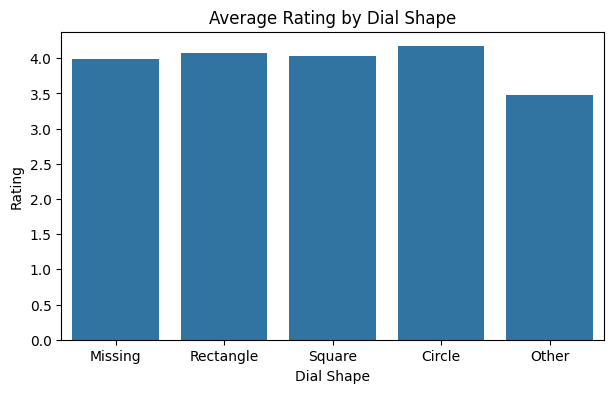

In [71]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=df,
    x="Dial Shape",
    y="Rating",
    estimator="mean",
    errorbar=None
)

plt.title("Average Rating by Dial Shape")
plt.show()

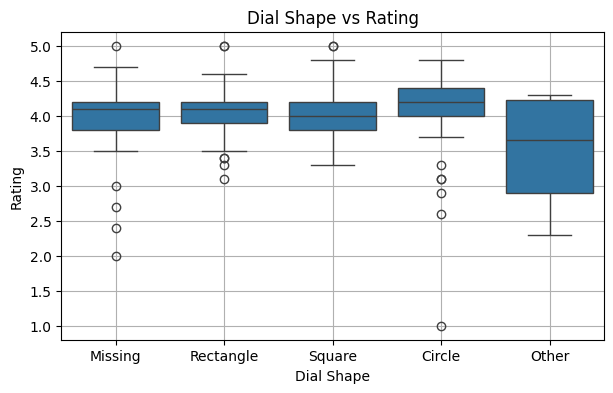

In [72]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Dial Shape",
    y="Rating"
)
plt.grid()
plt.title("Dial Shape vs Rating")
plt.show()

### Observations:
- Rectangle-shaped watches have the highest average rating, while Oval-shaped watches have the lowest average rating.
- The differences in average ratings among different dial shapes are very small.
- The median ratings across dial shapes are also relatively similar.
- Rectangle and Square dial shapes show relatively greater variation in ratings.
- Few dial shapes contain outliers, but no category exhibits extreme differences.

## Insight:

- Customer ratings remain relatively similar across different dial shapes. Although some dial shapes show slightly higher ratings, dial shape alone does not appear to strongly influence customer ratings.

## Strap Material VS Rating

In [73]:
strap_rating = (
    df.groupby("Strap Material")["Rating"]
      .mean()
      .sort_values()
)

print(strap_rating)

Strap Material
Stainless Steel    3.870000
Missing            3.922034
Rubber             4.045833
Other              4.087037
Silicon            4.101058
Leather            4.145455
Name: Rating, dtype: float64


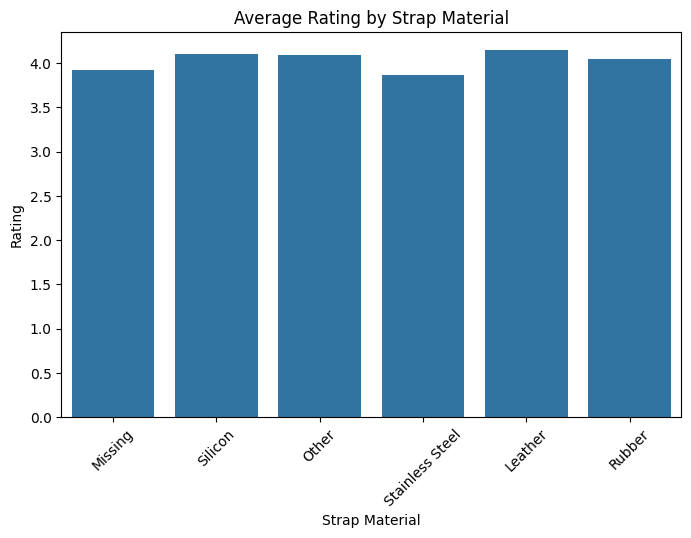

In [74]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Strap Material",
    y="Rating",
    estimator="mean",
    errorbar=None
)

plt.title("Average Rating by Strap Material")
plt.xticks(rotation=45)
plt.show()

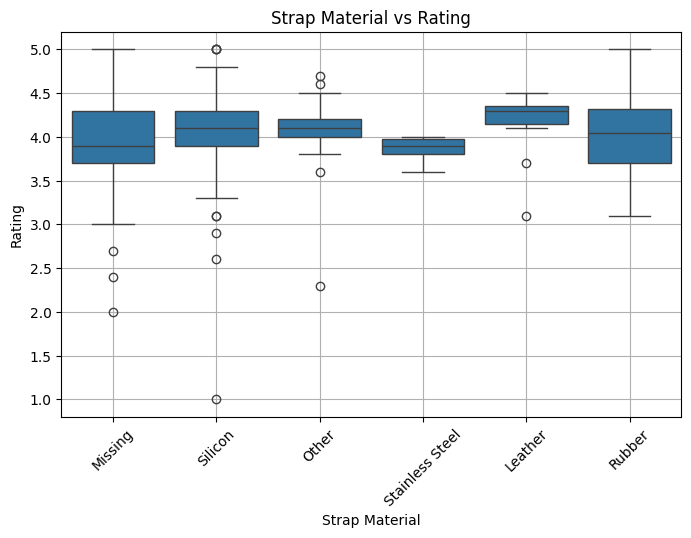

In [75]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Strap Material",
    y="Rating"
)
plt.grid()
plt.title("Strap Material vs Rating")
plt.xticks(rotation=45)
plt.show()

### Observations:
- Fabric straps have the highest average rating, while Plastic straps have the lowest average rating.
- The differences in average ratings across strap materials are relatively small.
- Rubber, Metal, and Missing categories have comparatively higher median ratings.
- Missing and Silicon categories show greater variation in ratings.
- No significant outliers are observed.

## Insight

- The average ratings across different strap materials are relatively similar. Although certain materials have slightly higher average ratings, strap material alone does not appear to have a strong association with customer ratings.

## Strap Color VS Rating

In [76]:
strap_color_rating = (
    df.groupby("Strap Color")["Rating"]
      .mean()
      .sort_values()
)

print(strap_color_rating)

Strap Color
Missing    3.987379
Black      4.041346
Blue       4.059259
Other      4.111628
Grey       4.237037
Name: Rating, dtype: float64


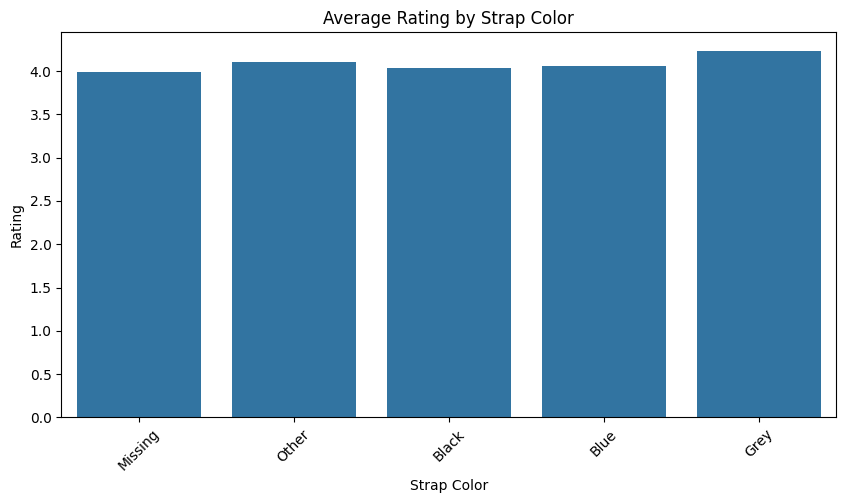

In [77]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Strap Color",
    y="Rating",
    estimator="mean",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Average Rating by Strap Color")
plt.show()

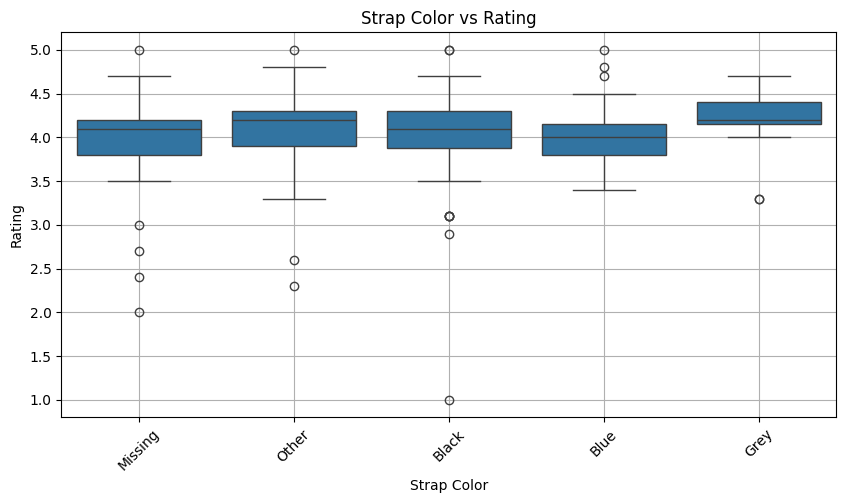

In [78]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Strap Color",
    y="Rating"
)
plt.grid()
plt.xticks(rotation=45)
plt.title("Strap Color vs Rating")
plt.show()

### Observations: 
- White Platinum has the highest average rating, while Wine has the lowest average rating.
- The average ratings across different strap colors are very similar.
- Burgundy has the highest median rating.
- Blue, Orange, Silver, and Misty Rose show relatively greater variation in ratings.
- The Missing category contains the highest number of outliers.

## Insight

- Customer ratings are relatively consistent across different strap colors. Although a few colors have slightly higher average ratings, strap color alone does not appear to significantly influence customer ratings.

## Bluetooth VS Rating

In [79]:
bluetooth_rating = (
    df.groupby("Bluetooth")["Rating"]
      .mean().sort_values()
)

print(bluetooth_rating)

Bluetooth
1    4.057514
0    4.700000
Name: Rating, dtype: float64


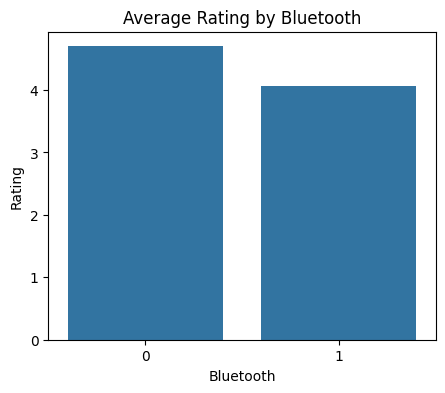

In [80]:
plt.figure(figsize=(5,4))

sns.barplot(
    data=df,
    x="Bluetooth",
    y="Rating",
    estimator="mean",
    errorbar=None
)

plt.title("Average Rating by Bluetooth")
plt.show()

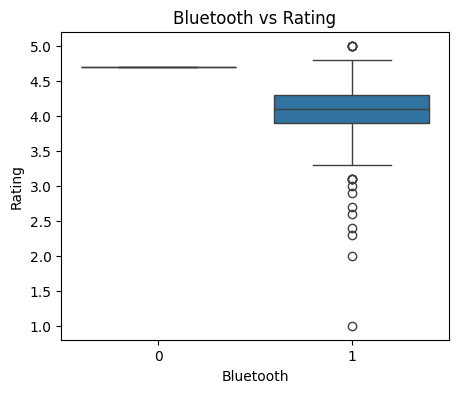

In [81]:
plt.figure(figsize=(5,4))

sns.boxplot(
    data=df,
    x="Bluetooth",
    y="Rating"
)

plt.title("Bluetooth vs Rating")
plt.show()

### Observations:
- Bluetooth-enabled watches (1) have a slightly higher average and median rating than watches without Bluetooth (0).
- The difference in ratings between the two categories is relatively small.
- Bluetooth-enabled watches exhibit greater variation in customer ratings.
- A few outliers are present in the Bluetooth-enabled category.

## Insight:

- Products with Bluetooth have slightly higher customer ratings than products without Bluetooth. However, the difference is small, indicating that Bluetooth alone is not a strong factor influencing customer ratings.

## Touchscreen VS Rating

In [82]:
touch_rating = (
    df.groupby("Touchscreen")["Rating"]
      .mean().sort_values()
)

print(touch_rating)

Touchscreen
1    4.048955
0    4.350000
Name: Rating, dtype: float64


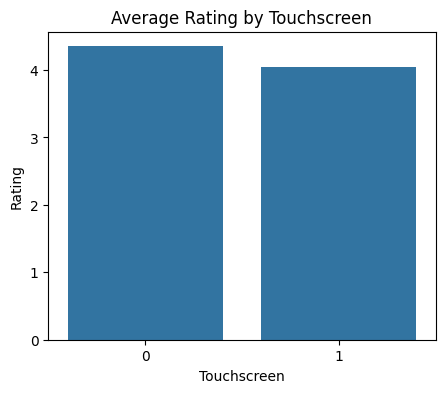

In [83]:
plt.figure(figsize=(5,4))

sns.barplot(
    data=df,
    x="Touchscreen",
    y="Rating",
    estimator="mean",
    errorbar=None
)

plt.title("Average Rating by Touchscreen")
plt.show()

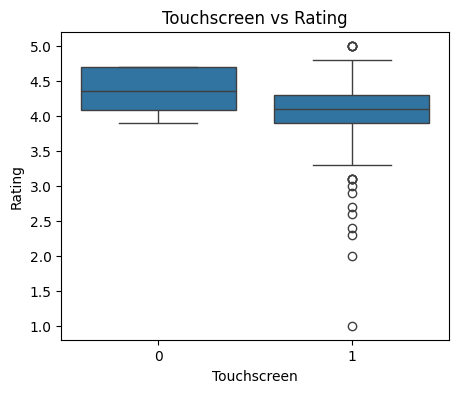

In [84]:
plt.figure(figsize=(5,4))

sns.boxplot(
    data=df,
    x="Touchscreen",
    y="Rating"
)

plt.title("Touchscreen vs Rating")
plt.show()

### Observations: 

- Non-touchscreen watches (0) have a slightly higher average and median rating than touchscreen watches (1).
- The difference in ratings between the two categories is very small.
- Touchscreen-enabled watches show greater variability in ratings.
- More outliers are observed in the touchscreen category.

## Insight:

- The average and median ratings of touchscreen and non-touchscreen watches are very similar. The small difference suggests that touchscreen availability alone is not strongly associated with customer ratings.

## Model Name

In [85]:
df["Model Name"].nunique()

306

### Observations:
- The feature contains 389 unique model names out of 436 observations, resulting in approximately 89% unique values.
- Most model names occur only once, making category-wise statistical analysis uninformative.
- Visualizations such as bar plots and box plots are not meaningful because most categories have only a single observation.
- One-Hot Encoding would create a large number of sparse features, increasing dimensionality.

## Insight:

- Model Name behaves more like a unique product identifier than a reusable predictive feature. It provides limited generalizable information for machine learning.

In [86]:
list(df.columns)

['Brand',
 'Current Price',
 'Original Price',
 'Discount Percentage',
 'Rating',
 'Number OF Ratings',
 'Model Name',
 'Dial Shape',
 'Strap Color',
 'Strap Material',
 'Touchscreen',
 'Battery Life (Days)',
 'Bluetooth',
 'Display Size',
 'Weight',
 'Weight_missing',
 'reviews_placeholder_flag',
 'price_logic_flag']